In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)
df_DA = df[df['job_title_short']== 'Data Analyst'].copy()

<Axes: xlabel='job_posted_month'>

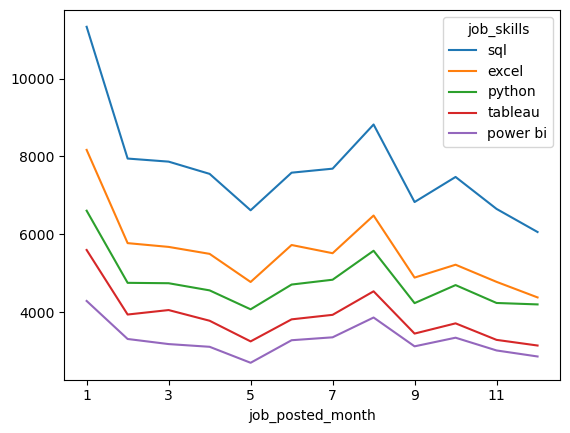

In [3]:
df_DA['job_posted_month'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')

df_DA_pivot = df_DA_explode.pivot_table(index= 'job_posted_month', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total']= df_DA_pivot.sum()
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).head().index]
df_DA_pivot=df_DA_pivot.drop('Total')
df_DA_pivot.plot(kind='line')

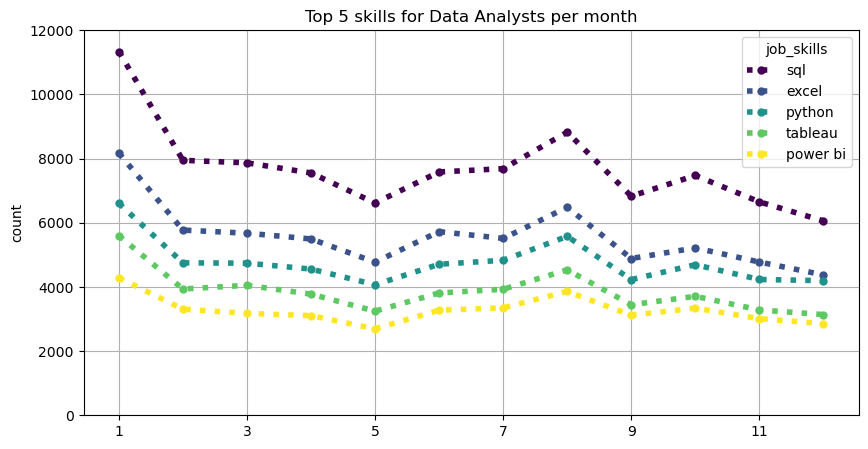

In [4]:
df_DA_pivot.plot(
    kind='line',
    linewidth=4,
    linestyle=':',
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(10,5)
)
plt.title('Top 5 skills for Data Analysts per month')
plt.ylabel('count')
plt.ylim(0,12000)
plt.grid(True)
plt.xlabel('')
plt.show()

In [22]:
df_exploded = df.explode('job_skills')
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count= ('job_skills', 'count'), 
    median_salary = ('salary_year_avg', 'median')
)
skill_stats = skill_stats.sort_values(by= 'skill_count', ascending=False).head(10)
skill_stats

,skill_count,median_salary
job_skills,,
sql,384849,120000.0
python,380909,125000.0
aws,145381,135000.0
azure,132527,125000.0
r,130892,119550.0
tableau,127213,111175.0
excel,127018,92500.0
spark,114609,140000.0
power bi,98147,102000.0


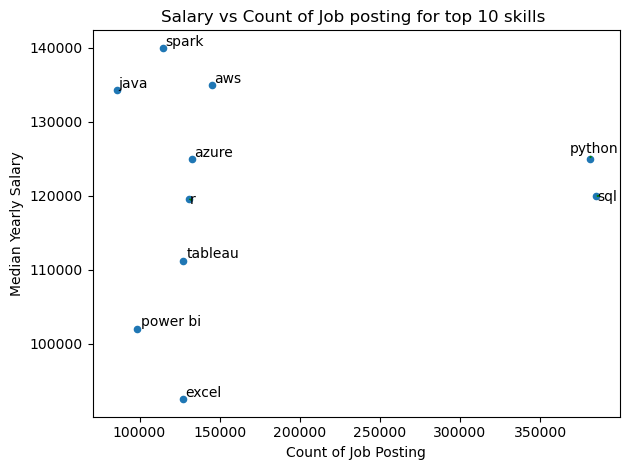

In [23]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x= 'skill_count', y='median_salary')
texts = []

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='g', lw=1))
plt.xlabel('Count of Job Posting')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs Count of Job posting for top 10 skills ')
plt.tight_layout()
plt.show()